In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sbn
from preprocessing import load_data, Feature_discretization_data

In [2]:
net_type = "String"
cell_type = "hESC"
gene_num =500

In [3]:
exp_file = '../Dataset/Benchmark Dataset/' + net_type + ' Dataset/' + cell_type + '/TFs+' + str(
        gene_num) + '/BL--ExpressionData.csv'
data_input = pd.read_csv(exp_file, index_col=0)

In [4]:
loader = load_data(data_input)
feature = loader.exp_data()
discretization_fea = Feature_discretization_data(data_input, 20)

In [5]:
data_input

,H9_00hb4s_001,H9_00hb4s_002,H9_00hb4s_003,H9_00hb4s_004,H9_00hb4s_005,H9_00hb4s_006,H9_00hb4s_007,H9_00hb4s_008,H9_00hb4s_009,H9_00hb4s_010,...,H9_96h_182,H9_96h_183,H9_96h_184,H9_96h_185,H9_96h_186,H9_96h_187,H9_96h_188,H9_96h_189,H9_96h_190,H9_96h_192
BTG2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.009428,2.191230,3.907733,0.000000,0.000000,6.309269,0.000000,0.000000,0.000000,7.709201
MIA3,0.000000,3.316020,5.526121,6.637142,6.240229,5.723449,6.277698,7.340640,6.521669,7.436972,...,8.952534,5.670650,7.268854,7.704264,0.000000,3.314508,6.127567,7.965957,6.517163,7.243577
GINS2,6.696841,7.385010,6.035999,6.068728,7.416978,7.024805,7.206360,6.617552,6.787199,7.444347,...,6.937273,4.812950,2.427000,6.610293,6.246854,4.109716,6.817364,0.000000,6.297394,6.012621
GYPB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.916895,...,7.579180,8.221955,6.717216,8.554925,9.190082,9.392196,8.994642,8.337842,9.162744,10.205212
MAN1A1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.698253,5.768296,8.909294,4.751893,4.219847,7.849769,0.000000,8.057030,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HSD17B11,0.000000,0.000000,6.709950,1.199451,5.003850,1.230227,0.000000,7.356572,6.011626,0.000000,...,6.094816,0.000000,0.000000,0.000000,6.959264,0.000000,5.819403,0.000000,0.000000,0.000000
ELL2,5.178932,5.753293,1.702251,1.199451,6.087286,0.000000,3.382085,0.925952,6.218315,5.831548,...,1.401970,0.000000,9.660197,7.602891,0.000000,7.946753,8.772237,9.267652,8.548685,9.089164
CTSK,4.978595,2.909914,5.985568,2.289707,2.362838,5.222769,3.975245,0.000000,0.000000,5.190690,...,0.000000,0.000000,0.000000,0.000000,5.180606,4.947262,0.880058,8.578751,0.000000,5.746577
RNF13,4.777109,7.072589,0.808477,5.651564,6.515278,7.926117,7.654962,7.814322,6.506243,6.354247,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.767431,0.857092,0.000000,6.552046


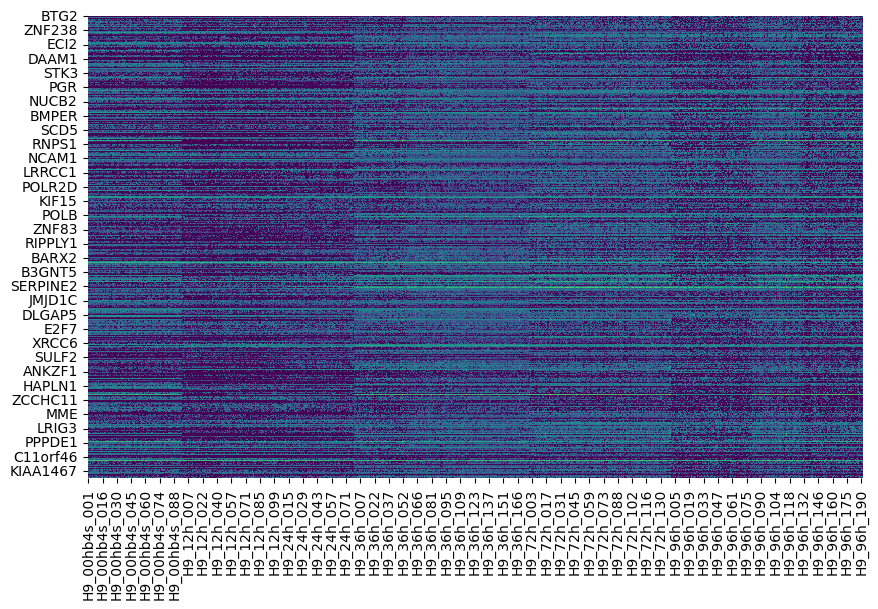

In [6]:
_, ax = plt.subplots(figsize=(10, 6))
ax = sbn.heatmap(data_input, cmap='viridis', cbar=False)
# ax.set_axis_off()
#plt.savefig('heatmap2.png', dpi=1080)

<Axes: >

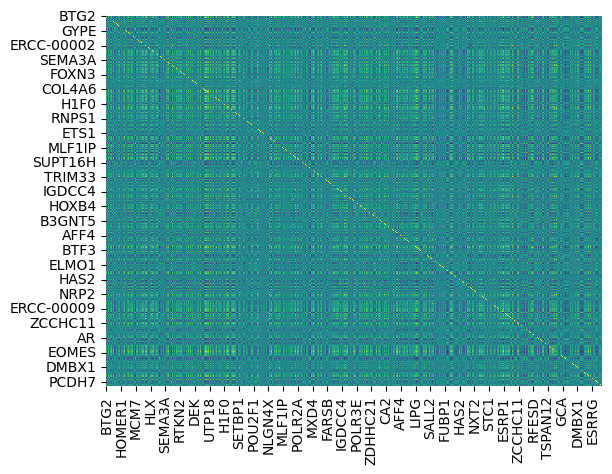

In [7]:
sbn.heatmap(data_input.T.corr(), cmap='viridis', cbar=False)

In [58]:

# 模拟原始基因表达矩阵数据 (N x F)
np.random.seed(42)
original_data = np.random.exponential(scale=5, size=10000)  # 模拟偏态分布数据

# 1. 标准化处理 (Standardization)
standardized_data = (original_data - np.mean(original_data)) / np.std(original_data)

# 2. 平滑化处理 (Smoothing)
# 简单平滑：用移动平均窗口
window_size = 10
smoothed_data = np.convolve(original_data, np.ones(window_size)/window_size, mode='same')

# 3. 离散化处理 (Discretization)
# 按百分位数离散化为低表达(0-33%)、中表达(33%-66%)、高表达(66%-100%)
cave = (original_data.max() - original_data.min()) / 20
discretized_data = np.floor(original_data / cave)


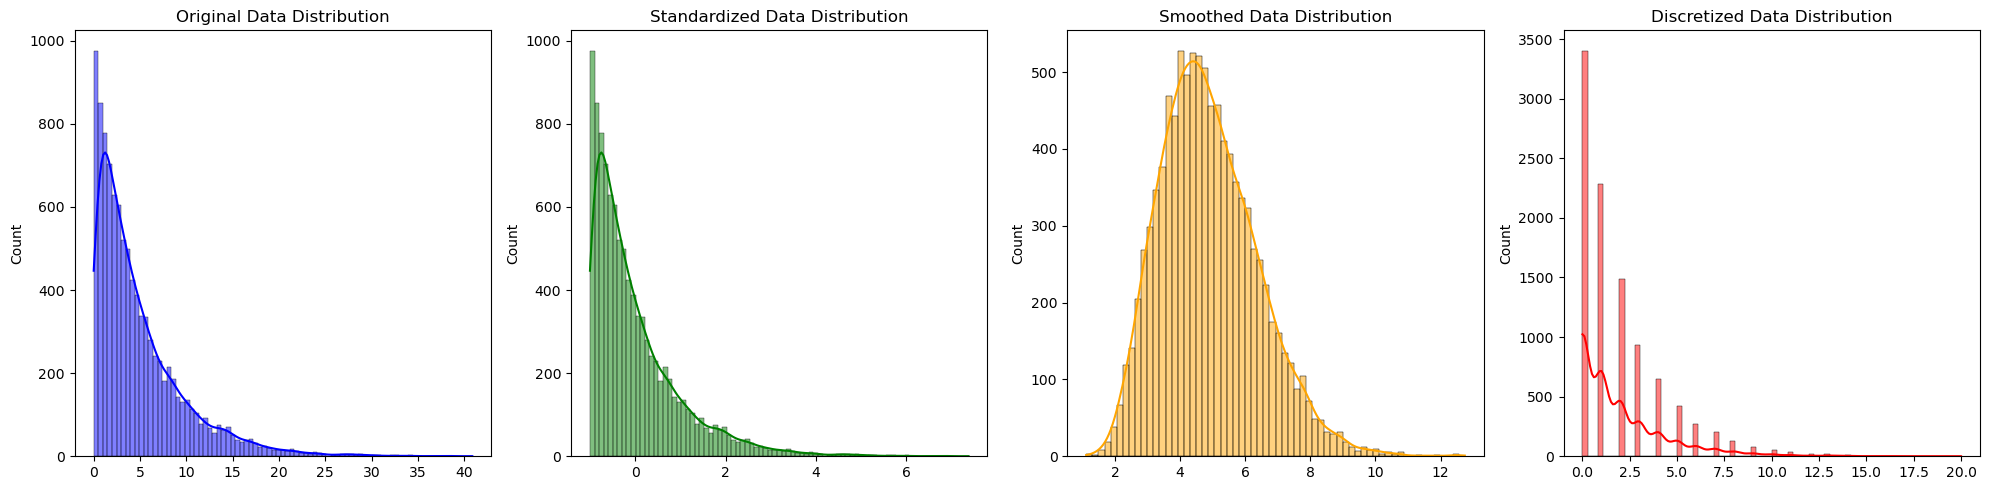

In [59]:
# 绘制分布图
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 原始数据分布
sbn.histplot(original_data, kde=True, ax=axes[0], color='blue')
axes[0].set_title("Original Data Distribution")

# 标准化数据分布
sbn.histplot(standardized_data, kde=True, ax=axes[1], color='green')
axes[1].set_title("Standardized Data Distribution")

# 平滑化数据分布
sbn.histplot(smoothed_data, kde=True, ax=axes[2], color='orange')
axes[2].set_title("Smoothed Data Distribution")

# 离散化数据分布
unique, counts = np.unique(discretized_data, return_counts=True)
sbn.histplot(discretized_data, kde=True, ax=axes[3], color='red')
axes[3].set_title("Discretized Data Distribution")

plt.tight_layout()
plt.show()

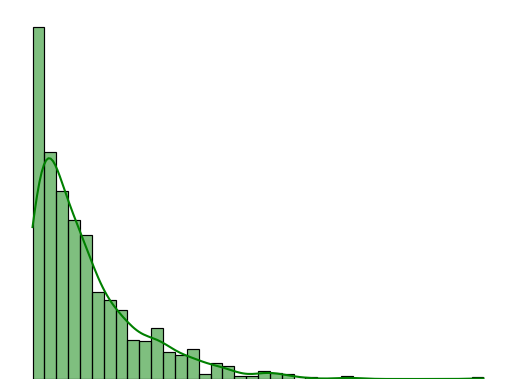

In [60]:
ax1 = sbn.histplot(standardized_data[:1000], kde=True, color='green')
ax1.set_axis_off()
plt.savefig("standardized.png", dpi = 2160)

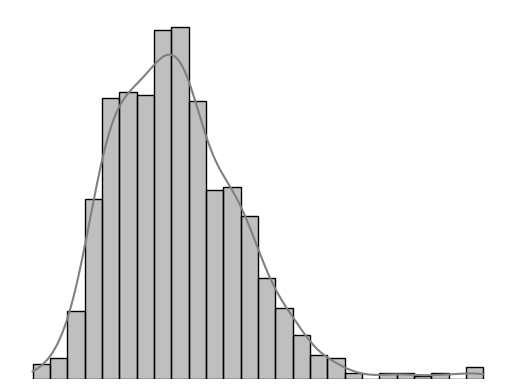

In [55]:
ax2 = sbn.histplot(smoothed_data[:1000], kde=True, color='grey')
ax2.set_axis_off()
plt.savefig("smoothed.png", dpi = 2160)

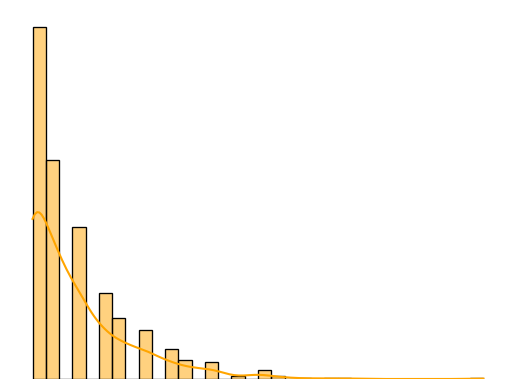

In [79]:
ax3 = sbn.histplot(discretized_data[:1000], kde=True, color='orange')
ax3.set_axis_off()
plt.savefig("discretized.png", dpi = 2160)

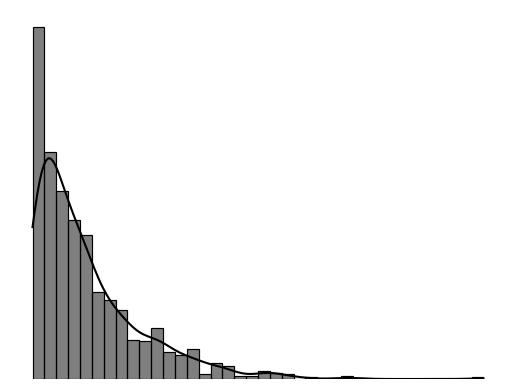

In [71]:
ax0 = sbn.histplot(original_data[:1000], kde=True, color='black')
ax0.set_axis_off()
plt.savefig("original.png", dpi = 2160)